In [1]:
import numpy as np
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from bluepysnap import Circuit
from bluepysnap.bbp import Cell

CircuitPath = 'O1_data_physiology/' # edges files not inclued in https://github.com/FernandoSBorges/
circuit_path = CircuitPath + 'circuit_config.json'
circuit = Circuit(circuit_path)
cells = circuit.nodes["S1nonbarrel_neurons"]
nodesinfo = cells.get()

# NetPyNE

In [2]:
from netpyne import specs, sim   

# Network parameters
netParams = specs.NetParams()  # object of class NetParams to store the network parameters

In [3]:
cellName_list = {}
cellName_list2 = []
gid_list = {}

Epops = ['L4_UPC_cADpyr_0']
Ipops = []

cellName_list2 = []

# for gid in [108767, 141766, 138433, 139867, 141213, 141369, 133426, 135956, 137858, 114264, 114284, 115007]: 
# for gid in [108767, 141766, 138433, 141213, 133426, 135956,  137858, 114264]: 
for gid in [114264]: 
# for gid in [118008, 118052, 118445, 118551, 118903, 119782, 120403, 121387, 122954, 123320, 123553, 125451, 125547, 127227, 127289, 129252, 130055, 130094, 130103, 130190, 130206, 130325, 131332, 131667, 131862, 132504, 132706, 133289, 133293, 133426, 133580, 134949, 135332, 135956, 137561, 137858]: 

    cellName = nodesinfo['mtype'][gid] + '_' + nodesinfo['etype'][gid]
        
    cellName_list2.append(cellName)
    
    cellName_list[gid] = cellName + '_' + str(len(cellName_list2)-1)
    gid_list[cellName + '_' + str(len(cellName_list2)-1)] = gid
    
    print('%s %s %s 1 1 %s %d' % (cellName + '_' + str(len(cellName_list2)-1),nodesinfo['mtype'][gid],nodesinfo['etype'][gid],nodesinfo['morphology'][gid],gid))

    if 'cADpyr' in cellName:
        Epops.append(cellName + '_' + str(len(cellName_list2)-1))
    else:
        Ipops.append(cellName + '_' + str(len(cellName_list2)-1))

L4_UPC_cADpyr_0 L4_UPC cADpyr 1 1 dend-rp120521_P_1_idC_axon-rp101229_L5-2_idE_-_Scale_x1.000_y0.950_z1.000 114264


In [4]:
cellsList = {}

for cellName in gid_list.keys():
    # try:    
        gid = gid_list[cellName]

        MorphoName = nodesinfo['morphology'][gid] + '.asc'

        hocName = nodesinfo['model_template'][gid][4:]  

        MorphologyPath = 'O1_data_physiology/morphologies/ascii'
        
        # MorphoName = nodesinfo['morphology'][gid]+"_gid"+str(gid)+".asc"

        print(cellName,hocName)
            
        cellRule = netParams.importCellParams(label=cellName, somaAtOrigin=True,
            conds={'cellType': cellName, 'cellModel': 'HH_full'},
            fileName='O1_data_physiology/emodels_hoc/' + hocName + '.hoc',
            cellName=hocName,
            cellInstance = False,
            cellArgs=[gid, MorphologyPath, MorphoName])
        
        # netParams.saveCellParamsRule(label=cellName, fileName=cellName+'_BBP_cellParams.json')


        # netParams.cellParams[cellName]['secs']['axon_0']['geom']['Ra'] = 2.0*netParams.cellParams[cellName]['secs']['axon_0']['geom']['Ra']

        cellsList[cellName] = [{'x': nodesinfo['x'][gid], 'y': nodesinfo['y'][gid], 'z': nodesinfo['z'][gid]}]
        # cellsList[cellName] = [{'x': nodesinfo['x'][gid] - 3000.0, 'y': nodesinfo['y'][gid] + 2000.0, 'z': nodesinfo['z'][gid] + 3500.0}]

        cellMe = cellName

        axon_pt3d_x, axon_pt3d_y, axon_pt3d_z, soma_pt3d_diam =  netParams.cellParams[cellMe]['secs']['soma_0']['geom']['pt3d'][-1]

        netParams.cellParams[cellMe]['secs']['axon_0']['geom']['diam'] = 1.0
        # netParams.cellParams[cellMe]['secs']['axon_0']['geom']['L'] = 30.0

        axon_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['diam']
        axon_pt3d_L =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['L']

        netParams.cellParams[cellMe]['secs']['axon_0']['geom']['pt3d'] = [(axon_pt3d_x, axon_pt3d_y, axon_pt3d_z, axon_pt3d_diam),
                                                                                    (axon_pt3d_x, axon_pt3d_y+axon_pt3d_L/2.0, axon_pt3d_z, axon_pt3d_diam),
                                                                                    (axon_pt3d_x, axon_pt3d_y+axon_pt3d_L, axon_pt3d_z, axon_pt3d_diam)]



        axon1_pt3d_x, axon1_pt3d_y, axon1_pt3d_z, axon_0_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['pt3d'][-1]

        # netParams.cellParams[cellMe]['secs']['axon_1']['geom']['diam'] = 0.5
        # netParams.cellParams[cellMe]['secs']['axon_1']['geom']['L'] = 30.0

        axon1_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['diam']
        axon1_pt3d_L =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['L']

        netParams.cellParams[cellMe]['secs']['axon_1']['geom']['pt3d'] = [(axon1_pt3d_x, axon1_pt3d_y, axon1_pt3d_z, axon1_pt3d_diam),
                                                                                    (axon1_pt3d_x, axon1_pt3d_y+axon1_pt3d_L/2.0, axon1_pt3d_z, axon1_pt3d_diam),
                                                                                    (axon1_pt3d_x, axon1_pt3d_y+axon1_pt3d_L, axon1_pt3d_z, axon1_pt3d_diam)] 


                    
        myelin_pt3d_x, myelin_pt3d_y, myelin_pt3d_z, axon_1_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['pt3d'][-1]

        # netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['diam'] = 0.5
        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['L'] = 100.0

        myelin_pt3d_diam =  netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['diam']
        myelin_pt3d_L =  netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['L']

        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['pt3d'] = [(myelin_pt3d_x, myelin_pt3d_y, myelin_pt3d_z, myelin_pt3d_diam),
                                                                                    (myelin_pt3d_x, myelin_pt3d_y+myelin_pt3d_L/2.0, myelin_pt3d_z, myelin_pt3d_diam),
                                                                                    (myelin_pt3d_x, myelin_pt3d_y+myelin_pt3d_L, myelin_pt3d_z, myelin_pt3d_diam)] 

    # except:
    #     pass        

# cellsList

L4_UPC_cADpyr_0 cADpyr_L4TPC


In [5]:
# https://github.com/suny-downstate-medical-center/S1_mouse
# Layer	     height	  from	  to
# L1         0.089      0.000	0.089
# L2         0.070      0.089	0.159
# L3         0.128      0.159	0.286
# L4         0.134      0.286	0.421
# L5         0.263      0.421	0.684
# L6         0.316      0.684	1.000			 
# L23        0.198      0.089	0.286
# All     1378.8 um

layer = {'1':[0.0, 0.089], '2': [0.089,0.159], '3': [0.159,0.286], '23': [0.089,0.286], '4':[0.286,0.421], '5': [0.421,0.684], '6': [0.684,1.0], 
'longS1': [2.2,2.3], 'longS2': [2.3,2.4]}  # normalized layer boundaries

#Th pop
ymin={'ss_RTN_o': 1688, 'ss_RTN_m': 1766, 'ss_RTN_i': 1844, 'VPL_sTC': 2000, 'VPM_sTC': 2156, 'POm_sTC_s1': 2312}
ymax={'ss_RTN_o': 1766, 'ss_RTN_m': 1844, 'ss_RTN_i': 2000, 'VPL_sTC': 2156, 'VPM_sTC': 2312, 'POm_sTC_s1': 2624}

#------------------------------------------------------------------------------
# General network parameters
#------------------------------------------------------------------------------
netParams.scale = 1.0 # Scale factor for number of cells
netParams.sizeX = 50.0 # x-dimension (horizontal length) size in um
netParams.sizeY = 1378.8 # y-dimension (vertical height or cortical depth) size in um
netParams.sizeZ = 50.0 # z-dimension (horizontal depth) size in um
netParams.shape = 'cylinder' # cylindrical (column-like) volume
netParams.rotateCellsRandomly = True
   
netParams.defaultThreshold = -20.0 # spike threshold, 10 mV is NetCon default, lower it for all cells
netParams.defaultDelay = 0.1 # default conn delay (ms)
netParams.propVelocity = 300.0 #  300 μm/ms (Stuart et al., 1997)
netParams.scaleConnWeightNetStims = 0.001  # weight conversion factor (from nS to uS)
    
#------------------------------------------------------------------------------
# load data from S1 Raster
#------------------------------------------------------------------------------
for cellName in netParams.cellParams.keys():    
    netParams.popParams[cellName] = {'cellType': cellName, 'cellsList': cellsList[cellName], 'cellModel': 'HH_full'}

In [6]:
popName1 = cellName_list[gid]
netParams.stimSourceParams['Input_'+str(gid)] = {'type': 'IClamp', 'del': 400.0, 'dur': 12.0, 'amp': 0.5}
netParams.stimTargetParams['Input->'+str(gid)] = {'source': 'Input_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}

In [7]:
#------------------------------------------------------------------------------
#
# SIMULATION CONFIGURATION
#
#------------------------------------------------------------------------------

cfg = specs.SimConfig()					            # object of class SimConfig to store simulation configuration

cfg.coreneuron = False

#------------------------------------------------------------------------------
# Run parameters
#------------------------------------------------------------------------------
cfg.duration = 0.60*1e3 ## Duration of the sim, in ms  
cfg.dt = 0.025
cfg.seeds = {'cell': 4321, 'conn': 4321, 'stim': 1000, 'loc': 4321} 
cfg.hParams = {'celsius': 34, 'v_init': -84.0}  
cfg.verbose = False
cfg.createNEURONObj = True
cfg.createPyStruct = True  
cfg.cvode_active = False
cfg.cvode_atol = 1e-6
cfg.cache_efficient = True
cfg.printRunTime = 0.1

cfg.includeParamsLabel = False
cfg.printPopAvgRates = True
cfg.checkErrors = False

#--------------------------------------------------------------------------
# Recording 
#--------------------------------------------------------------------------
cfg.recordCells = ['L4_UPC_cADpyr_0']
# cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'}}  ## Dict with traces to record  
cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_0': {'sec':'axon_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_1': {'sec':'axon_1', 'loc':0.5, 'var':'v'},
                    # 'V_myelin_0': {'sec':'myelin_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_15': {'sec':'axon_15', 'loc':0.5, 'var':'v'},
                    # 'V_apic_0': {'sec':'apic_0', 'loc':0.5, 'var':'v'},
                    # 'V_apic_7': {'sec':'apic_7', 'loc':0.5, 'var':'v'},       
                    # 'V_apic_64': {'sec':'apic_64', 'loc':0.5, 'var':'v'},
                    # 'V_apic_86': {'sec':'apic_86', 'loc':0.5, 'var':'v'},           
                    # 'V_dend_0': {'sec':'dend_0', 'loc':0.5, 'var':'v'},       
                    # 'V_dend_5': {'sec':'dend_5', 'loc':0.5, 'var':'v'},
                    }
cfg.recordStim = False			
cfg.recordTime = False  		
cfg.recordStep = 0.025       

# cfg.saveLFPPops =  cfg.recordCells 

# cfg.recordLFP = [[x, y, 15] for y in [400, 500, 600] for x in [0, 15, 30]] # 1 elec in L1 and 3 elec in L5  
cfg.recordLFP = [[x, y, 250] for y in [400, 500, 600] for x in [-200, 50, 300]] # 1 elec in L1 and 3 elec in L5  

#------------------------------------------------------------------------------
# Saving
#------------------------------------------------------------------------------
cfg.simLabel = 'v0_batch0'       #   + str(cfg.cynradNumber)
cfg.saveFolder = 'exploration/data/'+cfg.simLabel
# cfg.filename =                	## Set file output name
cfg.savePickle = False	        	## Save pkl file
cfg.saveJson = False           	## Save json file
cfg.saveDataInclude = ['simData', 'simConfig', 'net', 'netParams'] ## ['simData'] ##  ['simData'] ##, , 'simConfig', 'netParams'
cfg.backupCfgFile = None 		##  
cfg.gatherOnlySimData = False	##  
cfg.saveCellSecs = True			
cfg.saveCellConns = True	

#------------------------------------------------------------------------------
# Analysis and plotting 
# ------------------------------------------------------------------------------
# cfg.analysis['plotRaster'] = {'include': cfg.S1cells, 'saveFig': True, 'showFig': False,'orderInverse': True, 'timeRange': [0,cfg.duration], 'figSize': (24,8), 'fontSize':4, 'markerSize':4, 'marker': 'o', 'dpi': 300} 
# cfg.analysis['plot2Dnet']   = {'include': ['presyn_L23_PC_cAD','presyn_L5_TTPC2_cAD', 'presyn_VPM_sTC','L23_PC_cAD','L5_TTPC2_cAD'],'saveFig': True, 'showConns': False, 'figSize': (24,24), 'view': 'xz', 'fontSize':16}   # Plot 2D cells xy
# cfg.analysis['plotTraces'] = {'include': cfg.recordCells, 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'ylim': [-100,50], 'saveFig': True, 'showFig': False, 'figSize':(24,24)}

cfg.analysis['plotTraces'] = {'include': cfg.recordCells, 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'saveFig': False, 'showFig': True, 'figSize':(24,4)} # , 'ylim': [-90,30] Plot recorded traces for this list of cells
# cfg.analysis['plotShape'] = {'includePre':  [ii for ii in range(10)],'includePre':  [ii for ii in range(10)], 'saveFig': True, 'showFig': True, 'figSize':(12,12)}

cfg.recordLFP

[[-200, 400, 250],
 [50, 400, 250],
 [300, 400, 250],
 [-200, 500, 250],
 [50, 500, 250],
 [300, 500, 250],
 [-200, 600, 250],
 [50, 600, 250],
 [300, 600, 250]]

In [8]:
#------------------------------------------------------------------------------  
# Thalamic Cells

cfg.cellNumber = {}
cfg.popLabel = {}
cfg.popNumber = {}
 
cfg.thalamicpops = ['VPM_sTC']
cfg.cellNumber['VPM_sTC'] = 10 # 839

for mtype in cfg.thalamicpops: # No diversity
	metype = mtype
	cfg.popLabel[metype] = mtype
	cfg.popNumber[mtype] = cfg.cellNumber[metype]

## Th->S1
cfg.connect_ThVecStim_S1 = True
cfg.TC_S1 = {}
cfg.TC_S1['VPM_sTC'] = True
cfg.TC_S1_weightE = 0.00010
cfg.TC_S1_weightI = 0.00010

# homogeneous_poisson at 3Hz cos wave and FR~30Hz
cfg.tmin = 300
cfg.tdur = 40
cfg.max_rate = 1.00
cfg.f_osc = 0.010
cfg.bin_size = 150.0

# Th
netParams.synMechParams['NMDA_Th']             = {'mod': 'MyExp2SynNMDABB',    'tau1NMDA': 15, 'tau2NMDA': 150,                'e': 0}
netParams.synMechParams['AMPA_Th']             = {'mod': 'MyExp2SynBB',        'tau1': 0.05,   'tau2': 5.3, 'e': 0}
netParams.synMechParams['GABAB_Th']            = {'mod': 'MyExp2SynBB',        'tau1': 3.5,    'tau2': 260.9,                  'e': -93} 
netParams.synMechParams['GABAA_Th']            = {'mod': 'MyExp2SynBB',        'tau1': 0.07,   'tau2': 18.2,                   'e': -80}
ESynMech_Th = ['AMPA_Th', 'NMDA_Th']

#------------------------------------------------------------------------------
# ThVecStim->S1 connectivity parameters
#------------------------------------------------------------------------------
time = np.arange(0, cfg.tdur, 1)
rate = cfg.max_rate * (np.cos(2*np.pi*cfg.f_osc*time)+1)/2

allspikes = []

def inhomogeneous_poisson(rate, bin_size):
    n_bins = len(rate)
    spikes = np.random.rand(n_bins) < rate * bin_size
    spike_times = cfg.tmin + np.nonzero(spikes)[0] * bin_size
    print(spike_times)
    for spkk in spike_times:
        allspikes.append(spkk)
    return spike_times

# print(cfg.thalamicpops)
# create 1 vectstim pop per cell gid
for metype in cfg.thalamicpops: # metype

    # print(metype, cfg.cellNumber[metype])
    
    cellsList = []            
    for cellLabel in range(cfg.cellNumber[metype]): # all cells in metype
        spike_times = inhomogeneous_poisson(rate, cfg.bin_size)
        cellsList.append({'cellLabel': cellLabel, 'spkTimes': list(spike_times[:10])})
        # print(cellLabel, spike_times[::3])
        
    if np.size(cellsList) > 0:
        netParams.popParams[metype] = {'cellModel': 'VecStim', 'cellsList': cellsList}        


[ 300.  450.  600.  750.  900. 1050. 1200. 1350. 1500. 1650. 1800. 1950.
 2100. 2250. 2400. 2550. 2700. 2850. 3000. 3150. 3300. 3450. 3600. 3750.
 3900. 4050. 4200. 4350. 4500. 4650. 4800. 4950. 5100. 5250. 5400. 5550.
 5700. 5850. 6000. 6150.]
[ 300.  450.  600.  750.  900. 1050. 1200. 1350. 1500. 1650. 1800. 1950.
 2100. 2250. 2400. 2550. 2700. 2850. 3000. 3150. 3300. 3450. 3600. 3750.
 3900. 4050. 4200. 4350. 4500. 4650. 4800. 4950. 5100. 5250. 5400. 5550.
 5700. 5850. 6000. 6150.]
[ 300.  450.  600.  750.  900. 1050. 1200. 1350. 1500. 1650. 1800. 1950.
 2100. 2250. 2400. 2550. 2700. 2850. 3000. 3150. 3300. 3450. 3600. 3750.
 3900. 4050. 4200. 4350. 4500. 4650. 4800. 4950. 5100. 5250. 5400. 5550.
 5700. 5850. 6000. 6150.]
[ 300.  450.  600.  750.  900. 1050. 1200. 1350. 1500. 1650. 1800. 1950.
 2100. 2250. 2400. 2550. 2700. 2850. 3000. 3150. 3300. 3450. 3600. 3750.
 3900. 4050. 4200. 4350. 4500. 4650. 4800. 4950. 5100. 5250. 5400. 5550.
 5700. 5850. 6000. 6150.]
[ 300.  450.  600.  

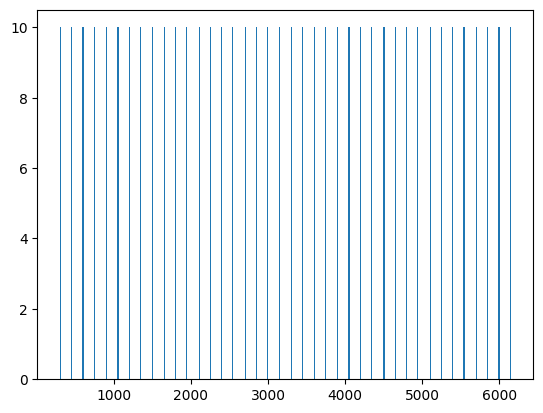

In [9]:
plt.hist(allspikes, bins=400);

In [10]:

# if cfg.connect_ThVecStim_S1:

#     # for post in Epops: 
#     #     convergence_Th_S1['VPM_sTC']['L4_PC'] = 197
#     #     convergence_Th_S1['VPM_sTC']['L4_SP'] = 197
#     #     convergence_Th_S1['VPM_sTC']['L4_SS'] = 188
#     #     convergence_Th_S1['VPM_sTC']['L4_INH'] = 116

#     ## Connectivity rules
#     synapsesperconnection_Th_S1 = 9.0
#     for pre in ['VPM_sTC']:  #  
#         if cfg.TC_S1[pre]:
#             post = 'L4_TPC_cADpyr_0'
#             conn_convergence = np.ceil(197/synapsesperconnection_Th_S1)
#             netParams.connParams['thal_'+pre+'_'+post] = { 
#                     'preConds': {'pop': pre},  ####################################################
#                     'postConds': {'pop': post},
#                     'weight': 0.0005,   # synaptic weight 
#                     'sec': 'all', # target postsyn section
#                     'delay': 'defaultDelay',
#                     'synsPerConn': int(synapsesperconnection_Th_S1),                     
#                     'synMech': ESynMech_Th,
#                     'convergence': conn_convergence } 


# conexão Thalamus -> célula L4 TPC (a única simulada)
netParams.connParams['VPM->L4UPC'] = {
    'preConds': {'pop': 'VPM_sTC'},     # origem = thalamic VecStim
    'postConds': {'cellModel': 'HH_full'},  # destino = sua célula excit.
    'weight': 0.00009,   
    'delay': 1,       
    'synsPerConn': 10,
    'synMech': 'AMPA'  
}


In [11]:
netParams.synMechParams['AMPA'] = {'mod': 'Exp2Syn', 'tau1': 0.5, 'tau2': 3.0, 'e': 0}

In [12]:
# #------------------------------------------------------------------------------
# # NetStim inputs to simulate Spontaneous synapses + background in S1 neurons - data from Rat
# #------------------------------------------------------------------------------
# # Spont and BG
# netParams.synMechParams['AMPA'] = {'mod':'MyExp2SynBB', 'tau1': 0.2, 'tau2': 1.74, 'e': 0}
# netParams.synMechParams['NMDA'] = {'mod': 'MyExp2SynNMDABB', 'tau1NMDA': 0.29, 'tau2NMDA': 43, 'e': 0}
# netParams.synMechParams['GABAA'] = {'mod':'MyExp2SynBB', 'tau1': 0.2, 'tau2': 8.3, 'e': -80}
# netParams.synMechParams['GABAB'] = {'mod':'MyExp2SynBB', 'tau1': 3.5, 'tau2': 260.9, 'e': -93} 
# ESynMech = ['AMPA', 'NMDA']
# ISynMech = ['GABAA', 'GABAB']

# cfg.addStimSynS1 = True

# cfg.Epops = Epops
# cfg.rateStimE = 50.0
# SourcesNumber = 20 # for each post Mtype - sec distribution

# if cfg.addStimSynS1:      
#     for post in cfg.Epops:

#         synperNeuron = 10
#         ratespontaneous = cfg.rateStimE
#         for qSnum in range(SourcesNumber):
#             ratesdifferentiation = (0.8 + 0.4*qSnum/(SourcesNumber-1)) * (synperNeuron*ratespontaneous)/SourcesNumber
#             netParams.stimSourceParams['StimSynS1_S_all_EXC->' + post + '_' + str(qSnum)] = {'type': 'NetStim', 'rate': ratesdifferentiation, 'noise': 1.0}
            
#     #------------------------------------------------------------------------------
#     # for post in cfg.Epops+cfg.Ipops:
#     #     for qSnum in range(SourcesNumber):
#     #         netParams.stimTargetParams['StimSynS1_T_all_EXC->' + post + '_' + str(qSnum)] = {
#     #             'source': 'StimSynS1_S_all_EXC->' + post + '_' + str(qSnum), 
#     #             'synMech': 'AMPA', 
#     #             'conds': {'cellType': post}, 
#     #             'sec': 'all', 
#     #             'weight': 0.5,
#     #             'delay': 0.1}

#     # for post in cfg.Epops+cfg.Ipops:
#     #     for qSnum in range(SourcesNumber):
#     #         netParams.stimTargetParams['StimSynS1_T_all_INH->' + post + '_' + str(qSnum)] = {
#     #             'source': 'StimSynS1_S_all_INH->' + post + '_' + str(qSnum), 
#     #             'conds': {'cellType': post}, 
#     #             'synMech': 'GABAA', 
#     #             'sec': 'all', 
#     #             'weight': 0.5,
#     #             'delay': 0.1}


In [13]:
sim.initialize(
    simConfig = cfg, 	
    netParams = netParams)  				# create network object and set cfg and net params
sim.net.createPops()               			# instantiate network populations
sim.net.createCells()              			# instantiate network cells based on defined populations
sim.net.connectCells()            			# create connections between cells based on params
sim.net.addStims() 							# add network stimulation
sim.setupRecording()              			# setup variables to record for each cell (spikes, V traces, etc)
sim.runSim()                      			# run parallel Neuron simulation  


Start time:  2025-09-18 13:39:45.613156

Creating network of 2 cell populations on 1 hosts...
  Number of cells on node 0: 11 
  Done; cell creation time = 0.03 s.
Making connections...
  Number of connections on node 0: 10 
  Number of synaptic contacts on node 0: 100 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 1 
  Done; cell stims creation time = 0.00 s.
Recording 1 traces of 1 types on node 0
0.0s

Running simulation using NEURON for 600.0 ms...
0.1s
0.2s
0.3s
0.4s
0.5s
0.6s
  Done; run time = 13.48 s; real-time ratio: 0.04.


In [14]:
#   Number of connections on node 0: 770 
#   Number of synaptic contacts on node 0: 21235 

In [15]:
sim.gatherData();                  			# gather spiking data and cell info from each node
# sim.saveData()                    			# save params, cell info and sim output to file (pickle,mat,txt,etc)#
# sim.analysis.plotData()         			# plot spike raster etc
# sim.analysis.plotSpikeStats(timeRange=[300,900], figSize=(18,6))


Gathering data...
  Done; gather time = 0.03 s.

Analyzing...
  Cells: 11
  Connections: 10 (0.91 per cell)
  Synaptic contacts: 100 (9.09 per cell)
  Spikes: 21 (3.18 Hz)
  Simulated time: 0.6 s; 1 workers
  Run time: 13.48 s
   L4_UPC_cADpyr_0 : 1.667 Hz
   VPM_sTC : 3.333 Hz


Plotting recorded cell traces ... trace


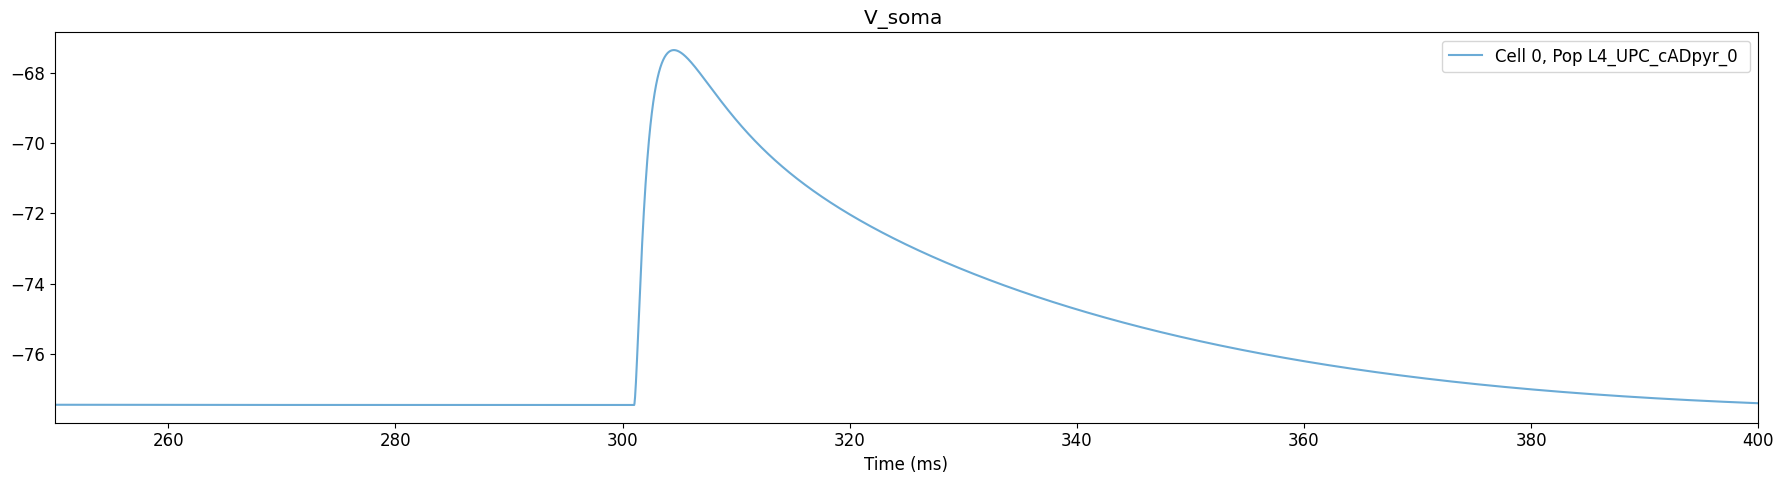

In [16]:
sim.analysis.plotTraces(timeRange=[250,400], overlay=True, oneFigPer='trace', figSize=(18,5), showFig=False, saveFig=False);
